<a href="https://colab.research.google.com/github/jupawest/SoSSProject/blob/main/Final_VoiceRecognitionModel_vers5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Enhanced Voice Authentication System
!pip install librosa numpy soundfile matplotlib scikit-learn joblib

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import lfilter, find_peaks
from scipy.spatial.distance import euclidean
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import joblib
from IPython.display import Javascript, display, Audio
from base64 import b64decode
import subprocess
from pathlib import Path
from google.colab import output, drive
import warnings
from typing import Tuple, List, Optional, Dict, Union
import json
import os
from datetime import datetime

# ==== Setup ====
drive.mount('/content/drive')
AUDIO_DIR = Path("/content/drive/MyDrive/voice_enrollments/train")
MODEL_DIR = Path("/content/drive/MyDrive/voice_models")
GRAPHS_DIR = Path("/content/drive/MyDrive/voice_graphs")  # New: For saving graphs
TEST_DIR = Path("/content/drive/MyDrive/voice_enrollments/test")

# Create directories
AUDIO_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
GRAPHS_DIR.mkdir(exist_ok=True)
TEST_DIR.mkdir(exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Javascript for browser-based audio recording
RECORD_JS = """
const sleep = t => new Promise(r=>setTimeout(r,t));
const readBlob = b=>new Promise(r=>{
  const fr = new FileReader();
  fr.onloadend = e => r(e.target.result);
  fr.readAsDataURL(b);
});
var record = t => new Promise(async r=>{
  const stream = await navigator.mediaDevices.getUserMedia({audio:true});
  const rec = new MediaRecorder(stream);
  const chunks = [];
  rec.ondataavailable = e => chunks.push(e.data);
  rec.start();
  await sleep(t);
  rec.stop();
  rec.onstop = async () => r(await readBlob(new Blob(chunks)));
});
"""

def record_audio(sec=5, wav_fn="input.wav"):
    """Record audio using browser microphone"""
    display(Javascript(RECORD_JS))
    data = output.eval_js(f"record({sec*1000})")
    raw_fn = "temp.webm"
    with open(raw_fn, 'wb') as f:
        f.write(b64decode(data.split(',')[1]))
    subprocess.run(
        ['ffmpeg', '-y', '-i', raw_fn, '-ar', '16000', '-ac', '1', wav_fn],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )
    return wav_fn

# === Enhanced Feature Extraction with Visualization ===

def extract_features(path: str, n_mfcc: int = 13) -> np.ndarray:
    """Extract MFCCs and additional features from an audio file."""
    try:
        y, sr = librosa.load(path, sr=16000)

        if len(y) == 0:
            warnings.warn(f"Empty audio file: {path}")
            return np.zeros(100)

        # Basic features
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_mean = np.mean(mfccs, axis=1)

        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)

        mel = librosa.feature.melspectrogram(y=y, sr=sr)
        mel_mean = np.mean(mel, axis=1)

        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        contrast_mean = np.mean(contrast, axis=1)

        tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)
        tonnetz_mean = np.mean(tonnetz, axis=1)

        features = np.hstack([
            mfccs_mean,
            chroma_mean,
            mel_mean,
            contrast_mean,
            tonnetz_mean
        ])

        return features

    except Exception as e:
        warnings.warn(f"Feature extraction failed for {path}: {e}")
        return np.zeros(100)

def create_audio_analysis(path: str, save_to_drive: bool = True):
    """
    Create comprehensive visualization of audio file and save to Google Drive
    """
    try:
        y, sr = librosa.load(path, sr=16000)
        filename = Path(path).stem

        # Create figure with subplots
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))
        fig.suptitle(f'Audio Analysis: {filename}', fontsize=16, fontweight='bold')

        # 1. Waveform
        axes[0, 0].set_title('Waveform')
        librosa.display.waveshow(y, sr=sr, ax=axes[0, 0])
        axes[0, 0].set_xlabel('Time (s)')
        axes[0, 0].set_ylabel('Amplitude')

        # 2. Spectrogram
        axes[0, 1].set_title('Spectrogram')
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
        librosa.display.specshow(D, y_axis='hz', x_axis='time', sr=sr, ax=axes[0, 1])
        axes[0, 1].set_ylabel('Frequency (Hz)')

        # 3. MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        axes[1, 0].set_title('MFCCs')
        librosa.display.specshow(mfccs, x_axis='time', ax=axes[1, 0])
        axes[1, 0].set_ylabel('MFCC Coefficients')

        # 4. Chroma Features
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        axes[1, 1].set_title('Chroma Features')
        librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', ax=axes[1, 1])

        # 5. Spectral Features Bar Chart
        mfcc_mean = np.mean(mfccs, axis=1)
        axes[2, 0].set_title('Average MFCC Coefficients')
        axes[2, 0].bar(range(len(mfcc_mean)), mfcc_mean)
        axes[2, 0].set_xlabel('MFCC Index')
        axes[2, 0].set_ylabel('Value')

        # 6. Mel Spectrogram
        mel = librosa.feature.melspectrogram(y=y, sr=sr)
        axes[2, 1].set_title('Mel Spectrogram')
        librosa.display.specshow(librosa.power_to_db(mel, ref=np.max),
                               y_axis='mel', x_axis='time', ax=axes[2, 1])

        plt.tight_layout()

        if save_to_drive:
            # Save to Google Drive
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            graph_filename = f"{filename}_analysis_{timestamp}.png"
            save_path = GRAPHS_DIR / graph_filename
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"📊 Graph saved to: {save_path}")

        plt.show()

        return save_path if save_to_drive else None

    except Exception as e:
        print(f"Error creating visualization for {path}: {e}")
        return None

def plot_waveform_and_mfcc(path: str, n_mfcc: int = 13):
    """Display waveform and MFCCs for quick inspection."""
    try:
        y, sr = librosa.load(path, sr=16000)

        plt.figure(figsize=(10, 3))
        plt.title(f"Waveform of {Path(path).name}")
        librosa.display.waveshow(y, sr=sr)
        plt.tight_layout()
        plt.show()

        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(mfccs, x_axis='time', sr=sr)
        plt.colorbar()
        plt.title(f"MFCC of {Path(path).name}")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error plotting audio {path}: {e}")

In [ ]:
# === Audio Comparison Functions ===

def compare_audio_features(audio1_path: str, audio2_path: str, save_comparison=True):
    """
    Compare two audio files and visualize the differences
    """
    try:
        # Load both audio files
        y1, sr1 = librosa.load(audio1_path, sr=16000)
        y2, sr2 = librosa.load(audio2_path, sr=16000)

        filename1 = Path(audio1_path).stem
        filename2 = Path(audio2_path).stem

        # Extract features for comparison
        features1 = extract_features(audio1_path)
        features2 = extract_features(audio2_path)

        # Calculate similarity metrics
        cosine_sim = cosine_similarity([features1], [features2])[0][0]
        euclidean_dist = euclidean(features1, features2)

        # Create comparison visualization
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle(f'Audio Comparison: {filename1} vs {filename2}', fontsize=16, fontweight='bold')

        # Waveforms comparison
        axes[0, 0].set_title('Waveform Comparison')
        time1 = np.linspace(0, len(y1)/sr1, len(y1))
        time2 = np.linspace(0, len(y2)/sr2, len(y2))
        axes[0, 0].plot(time1, y1, alpha=0.7, label=filename1, color='blue')
        axes[0, 0].plot(time2, y2, alpha=0.7, label=filename2, color='red')
        axes[0, 0].legend()
        axes[0, 0].set_xlabel('Time (s)')
        axes[0, 0].set_ylabel('Amplitude')

        # MFCCs comparison
        mfcc1 = librosa.feature.mfcc(y=y1, sr=sr1, n_mfcc=13)
        mfcc2 = librosa.feature.mfcc(y=y2, sr=sr2, n_mfcc=13)

        axes[0, 1].set_title(f'MFCC - {filename1}')
        librosa.display.specshow(mfcc1, x_axis='time', ax=axes[0, 1])

        axes[0, 2].set_title(f'MFCC - {filename2}')
        librosa.display.specshow(mfcc2, x_axis='time', ax=axes[0, 2])

        # Feature comparison bar chart
        mfcc1_mean = np.mean(mfcc1, axis=1)
        mfcc2_mean = np.mean(mfcc2, axis=1)

        x = np.arange(len(mfcc1_mean))
        width = 0.35

        axes[1, 0].set_title('Average MFCC Comparison')
        axes[1, 0].bar(x - width/2, mfcc1_mean, width, label=filename1, alpha=0.8, color='blue')
        axes[1, 0].bar(x + width/2, mfcc2_mean, width, label=filename2, alpha=0.8, color='red')
        axes[1, 0].set_xlabel('MFCC Index')
        axes[1, 0].set_ylabel('Value')
        axes[1, 0].legend()

        # Similarity metrics
        axes[1, 1].set_title('Similarity Metrics')
        metrics = ['Cosine Similarity', 'Euclidean Distance']
        values = [cosine_sim, euclidean_dist]
        colors = ['green' if cosine_sim > 0.8 else 'orange' if cosine_sim > 0.6 else 'red', 'blue']
        bars = axes[1, 1].bar(metrics, values, color=colors, alpha=0.7)
        axes[1, 1].set_ylim(0, 1.5) # Adjust ylim for better visualization

        # Add value labels on bars
        for bar, value in zip(bars, [cosine_sim, euclidean_dist]):
            height = bar.get_height()
            label = f'{value:.3f}'
            axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                           label, ha='center', va='bottom')

        # Spectrograms comparison
        D1 = librosa.amplitude_to_db(np.abs(librosa.stft(y1)), ref=np.max)
        D2 = librosa.amplitude_to_db(np.abs(librosa.stft(y2)), ref=np.max)

        axes[1, 2].set_title('Spectrogram Difference')
        # Resize spectrograms to same shape for comparison
        min_time = min(D1.shape[1], D2.shape[1])
        D1_resized = D1[:, :min_time]
        D2_resized = D2[:, :min_time]
        diff = np.abs(D1_resized - D2_resized)
        librosa.display.specshow(diff, y_axis='hz', x_axis='time', sr=sr1, ax=axes[1, 2])

        plt.tight_layout()

        # Print similarity results
        print(f"\n📊 Audio Comparison Results:")
        print(f"   Cosine Similarity: {cosine_sim:.4f} (Higher = More Similar)")
        print(f"   Euclidean Distance: {euclidean_dist:.4f} (Lower = More Similar)")

        if cosine_sim > 0.9:
            print("   🎯 Very High Similarity - Likely Same Speaker")
        elif cosine_sim > 0.8:
            print("   ✅ High Similarity - Probably Same Speaker")
        elif cosine_sim > 0.6:
            print("   ⚠️ Moderate Similarity - Uncertain")
        else:
            print("   ❌ Low Similarity - Likely Different Speakers")

        if save_comparison:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            comparison_filename = f"comparison_{filename1}_vs_{filename2}_{timestamp}.png"
            save_path = GRAPHS_DIR / comparison_filename
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"📊 Comparison graph saved to: {save_path}")

        plt.show()

        return {
            'cosine_similarity': cosine_sim,
            'euclidean_distance': euclidean_dist,
            'features1': features1,
            'features2': features2
        }

    except Exception as e:
        print(f"Error comparing audio files: {e}")
        return None

In [ ]:
def find_most_similar_enrolled_audio(test_audio_path: str, enrolled_audio_dir: Path = AUDIO_DIR):
    """
    Find the most similar enrolled audio file to a test recording
    """
    test_features = extract_features(test_audio_path)
    best_similarity = -1
    best_match = None
    best_speaker = None
    similarities = []

    print(f"🔍 Searching for similar audio in enrolled database...")

    for speaker_dir in enrolled_audio_dir.iterdir():
        if speaker_dir.is_dir():
            speaker_name = speaker_dir.name
            for audio_file in speaker_dir.glob("*.wav"):
                enrolled_features = extract_features(str(audio_file))
                similarity = cosine_similarity([test_features], [enrolled_features])[0][0]

                similarities.append({
                    'file': audio_file,
                    'speaker': speaker_name,
                    'similarity': similarity
                })

                if similarity > best_similarity:
                    best_similarity = similarity
                    best_match = audio_file
                    best_speaker = speaker_name

    # Sort by similarity
    similarities.sort(key=lambda x: x['similarity'], reverse=True)

    print(f"\n📈 Top 5 Most Similar Enrolled Recordings:")
    for i, sim in enumerate(similarities[:5]):
        print(f"   {i+1}. {sim['speaker']}/{sim['file'].name} - Similarity: {sim['similarity']:.4f}")

    if best_match:
        print(f"\n🎯 Best Match: {best_speaker}/{best_match.name} (Similarity: {best_similarity:.4f})")

        # Create comparison visualization
        comparison_result = compare_audio_features(test_audio_path, str(best_match))
        return best_match, best_speaker, best_similarity, comparison_result
    else:
        print("❌ No enrolled audio found for comparison")
        return None, None, 0, None

# === Original ML Functions (keeping existing functionality) ===

def prepare_dataset(audio_dir: Path, n_mfcc: int = 13):
    """Load dataset from audio directory and return X, y arrays."""
    X, y = [], []

    for speaker_dir in audio_dir.iterdir():
        if speaker_dir.is_dir():
            label = speaker_dir.name
            audio_files = list(speaker_dir.glob("*.wav"))
            print(f"Processing {label}: {len(audio_files)} files")

            for wav_file in audio_files:
                features = extract_features(str(wav_file), n_mfcc=n_mfcc)
                if features is not None and len(features) > 0:
                    X.append(features)
                    y.append(label)

    if len(X) == 0:
        raise ValueError("No valid audio files found in the dataset")

    return np.array(X), np.array(y)

def train_model(X: np.ndarray, y: np.ndarray, model_type: str = "rf"):
    """Train a classification model."""
    if len(X) == 0 or len(y) == 0:
        raise ValueError("Empty dataset provided")

    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    if model_type == "rf":
        model = RandomForestClassifier(n_estimators=100, random_state=42)
    elif model_type == "svm":
        model = SVC(probability=True, kernel="rbf", random_state=42)
    elif model_type == "mlp":
        model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

    model.fit(X_scaled, y_enc)

    pipeline = {
        "scaler": scaler,
        "model": model,
        "label_encoder": le
    }

    return pipeline


In [ ]:
import shutil

def evaluate_model(pipeline: Dict, X: np.ndarray, y: np.ndarray):
    """Evaluate trained model with classification report and confusion matrix."""
    scaler = pipeline["scaler"]
    model = pipeline["model"]
    le = pipeline["label_encoder"]

    X_scaled = scaler.transform(X)
    y_enc = le.transform(y)

    y_pred = model.predict(X_scaled)

    print("=== Classification Report ===")
    print(classification_report(y_enc, y_pred, target_names=le.classes_))

    print("=== Confusion Matrix ===")
    print(confusion_matrix(y_enc, y_pred))

def save_model(pipeline: Dict, model_path: Path):
    """Save trained pipeline to disk."""
    joblib.dump(pipeline, model_path)
    print(f"Model saved to {model_path}")

def load_model(model_path: Path):
    """Load trained pipeline from disk."""
    pipeline = joblib.load(model_path)
    print(f"Model loaded from {model_path}")
    return pipeline

def verify_speaker(pipeline: Dict, test_audio: str, threshold: float = 0.7) -> Tuple[bool, str, float]:
    """Verify speaker identity from a test audio file."""
    features = extract_features(test_audio)
    if features is None or len(features) == 0:
        return False, "unknown", 0.0

    features_scaled = pipeline["scaler"].transform([features])

    model = pipeline["model"]
    le = pipeline["label_encoder"]

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(features_scaled)[0]
        max_idx = np.argmax(probs)
        confidence = probs[max_idx]
        predicted_label = le.inverse_transform([max_idx])[0]
    else:
        pred = model.predict(features_scaled)[0]
        predicted_label = le.inverse_transform([pred])[0]
        confidence = 1.0

    is_verified = confidence >= threshold

    return is_verified, predicted_label, confidence

# === Enhanced Demo Functions with Visualization ===

def enroll_user_multiple(user_name: str, n_samples: int = 3):
    """Enroll multiple samples with visualization for each recording"""
    samples = []
    user_dir = AUDIO_DIR / user_name
    user_dir.mkdir(exist_ok=True)

    for i in range(n_samples):
        print(f"🎙️ Recording sample {i+1}/{n_samples} for {user_name}")
        wav_path = user_dir / f"sample{i+1}.wav"
        try:
            record_audio(sec=5, wav_fn=str(wav_path))
            samples.append(str(wav_path))
            print(f"✅ Sample {i+1} saved")

            # Create analysis for each sample
            print(f"📊 Creating analysis for sample {i+1}...")
            create_audio_analysis(str(wav_path))

        except Exception as e:
            print(f"❌ Failed to record sample {i+1}: {e}")

    print(f"✅ Enrolled {user_name} with {len(samples)} samples")
    return samples

def interactive_test(pipeline: Dict, num_tests: int = 2):
    """Interactive testing with automatic comparison to enrolled samples"""
    print(f"\n=== Interactive Testing with Comparison ===")
    print("Record test samples and compare them with enrolled audio!")

    for i in range(num_tests):
        print(f"\n--- Test {i+1}/{num_tests} ---")
        input("Press Enter when ready to record a 5-second test sample...")

        test_file = f"test_sample_{i+1}.wav"
        record_audio(sec=5, wav_fn=test_file)

        # Create analysis for test sample
        print("📊 Creating analysis for test sample...")
        create_audio_analysis(test_file)

        # Verify with ML model
        is_verified, predicted_label, confidence = verify_speaker(pipeline, test_file, threshold=0.7)

        status = "✅ Verified" if is_verified else "❌ Rejected"
        print(f"\n🤖 ML Model Result: {status}")
        print(f"   Predicted Speaker: {predicted_label}")
        print(f"   Confidence: {confidence:.3f}")

        # Find and compare with most similar enrolled audio
        print(f"\n🔍 Finding most similar enrolled recording...")
        best_match, best_speaker, similarity, comparison_result = find_most_similar_enrolled_audio(test_file)

        if comparison_result:
            print(f"\n📊 Direct Audio Comparison Results:")
            print(f"   Most Similar: {best_speaker}")
            print(f"   Cosine Similarity: {comparison_result['cosine_similarity']:.4f}")
            print(f"   Euclidean Distance: {comparison_result['euclidean_distance']:.4f}")

        # Move test file to test directory
        test_final_path = TEST_DIR / f"test_{datetime.now().strftime('%Y%m%d_%H%M%S')}_{i+1}.wav"
        shutil.move(test_file, test_final_path)
        print(f"📁 Test file saved to: {test_final_path}")

In [ ]:
def run_demo(audio_dir: Path, test_dir: Path = None, model_path: Path = None):
    """Full workflow with enhanced visualization"""
    try:
        print("\n=== Step 1: Preparing dataset ===")
        X, y = prepare_dataset(audio_dir)
        print(f"Loaded {len(X)} samples from {len(set(y))} speakers")

        if len(set(y)) < 2:
            print("⚠️ Warning: Only one speaker found. For proper testing, enroll multiple speakers.")

        print("\n=== Step 2: Training model ===")
        pipeline = train_model(X, y, model_type="rf")

        print("\n=== Step 3: Evaluating model (Train/Test Split) ===")
        if len(X) > 4:
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
            train_pipeline = train_model(X_train, y_train, model_type="rf")
            print("Evaluation on held-out test set:")
            evaluate_model(train_pipeline, X_test, y_test)
        else:
            print("Not enough samples for train/test split. Showing training performance:")
            evaluate_model(pipeline, X, y)

        if model_path:
            print("\n=== Step 4: Saving model ===")
            save_model(pipeline, model_path)
            print("\n=== Step 5: Reloading model ===")
            loaded_pipeline = load_model(model_path)
        else:
            loaded_pipeline = pipeline

        print("\n=== Step 6: Interactive testing ===")
        interactive_test(loaded_pipeline, num_tests=2)

    except Exception as e:
        print(f"Error in demo: {e}")
        raise


In [ ]:
def quick_start():
    """Complete workflow"""
    print("=== Voice Authentication System - Complete Workflow ===")
    print()
    print("🎯 Enhanced Features:")
    print("   • Comprehensive audio visualization")
    print("   • Automatic graph saving to Google Drive")
    print("   • Audio comparison with enrolled samples")
    print("   • ML model + direct audio similarity analysis")
    print()
    print("📝 Example workflow:")
    print()
    print("# Enroll users")
    print("enroll_user_multiple('alice', 3)")
    print("enroll_user_multiple('bob', 3)")
    print()
    print("# Train model and run demo")
    print("MODEL_PATH = MODEL_DIR / 'voice_model.pkl'")
    print("run_demo(AUDIO_DIR, model_path=MODEL_PATH)")
    print()
    print("# Compare specific audio files")
    print("compare_audio_features('audio1.wav', 'audio2.wav')")

def comprehensive_demo():
    """Run complete demonstration with all features"""
    print("🚀 Starting Comprehensive Voice Authentication Demo")

    try:
        enrolled_users = [d for d in AUDIO_DIR.iterdir() if d.is_dir()]

        if not enrolled_users:
            print("❌ No enrolled users found!")
            print("Please run enroll_user_with_visualization('username', 3) first")
            return

        print(f"✅ Found {len(enrolled_users)} enrolled users: {[u.name for u in enrolled_users]}")

        MODEL_PATH = MODEL_DIR / 'voice_auth_model_enhanced.pkl'
        run_demo(AUDIO_DIR, model_path=MODEL_PATH)

        print("\n" + "="*60)
        print("🎉 Enhanced Demo completed successfully!")
        print(f"📊 All graphs saved to: {GRAPHS_DIR}")
        print(f"🔧 Model saved to: {MODEL_PATH}")
        print("="*60)

    except Exception as e:
        print(f"❌ Demo failed: {e}")
        print("Make sure you have enrolled users first using enroll_user_multiple()")

In [ ]:
quick_start()

=== Voice Authentication System - Complete Workflow ===

🎯 Enhanced Features:
   • Comprehensive audio visualization
   • Automatic graph saving to Google Drive
   • Audio comparison with enrolled samples
   • ML model + direct audio similarity analysis

📝 Example workflow:

# Enroll users
enroll_user_multiple('alice', 3)
enroll_user_multiple('bob', 3)

# Train model and run demo
MODEL_PATH = MODEL_DIR / 'voice_model.pkl'
run_demo(AUDIO_DIR, model_path=MODEL_PATH)

# Compare specific audio files
compare_audio_features('audio1.wav', 'audio2.wav')


🎙️ Recording sample 1/3 for janedoe


<IPython.core.display.Javascript object>

✅ Sample 1 saved
📊 Creating analysis for sample 1...
📊 Graph saved to: /content/drive/MyDrive/voice_graphs/sample1_analysis_20250826_060532.png


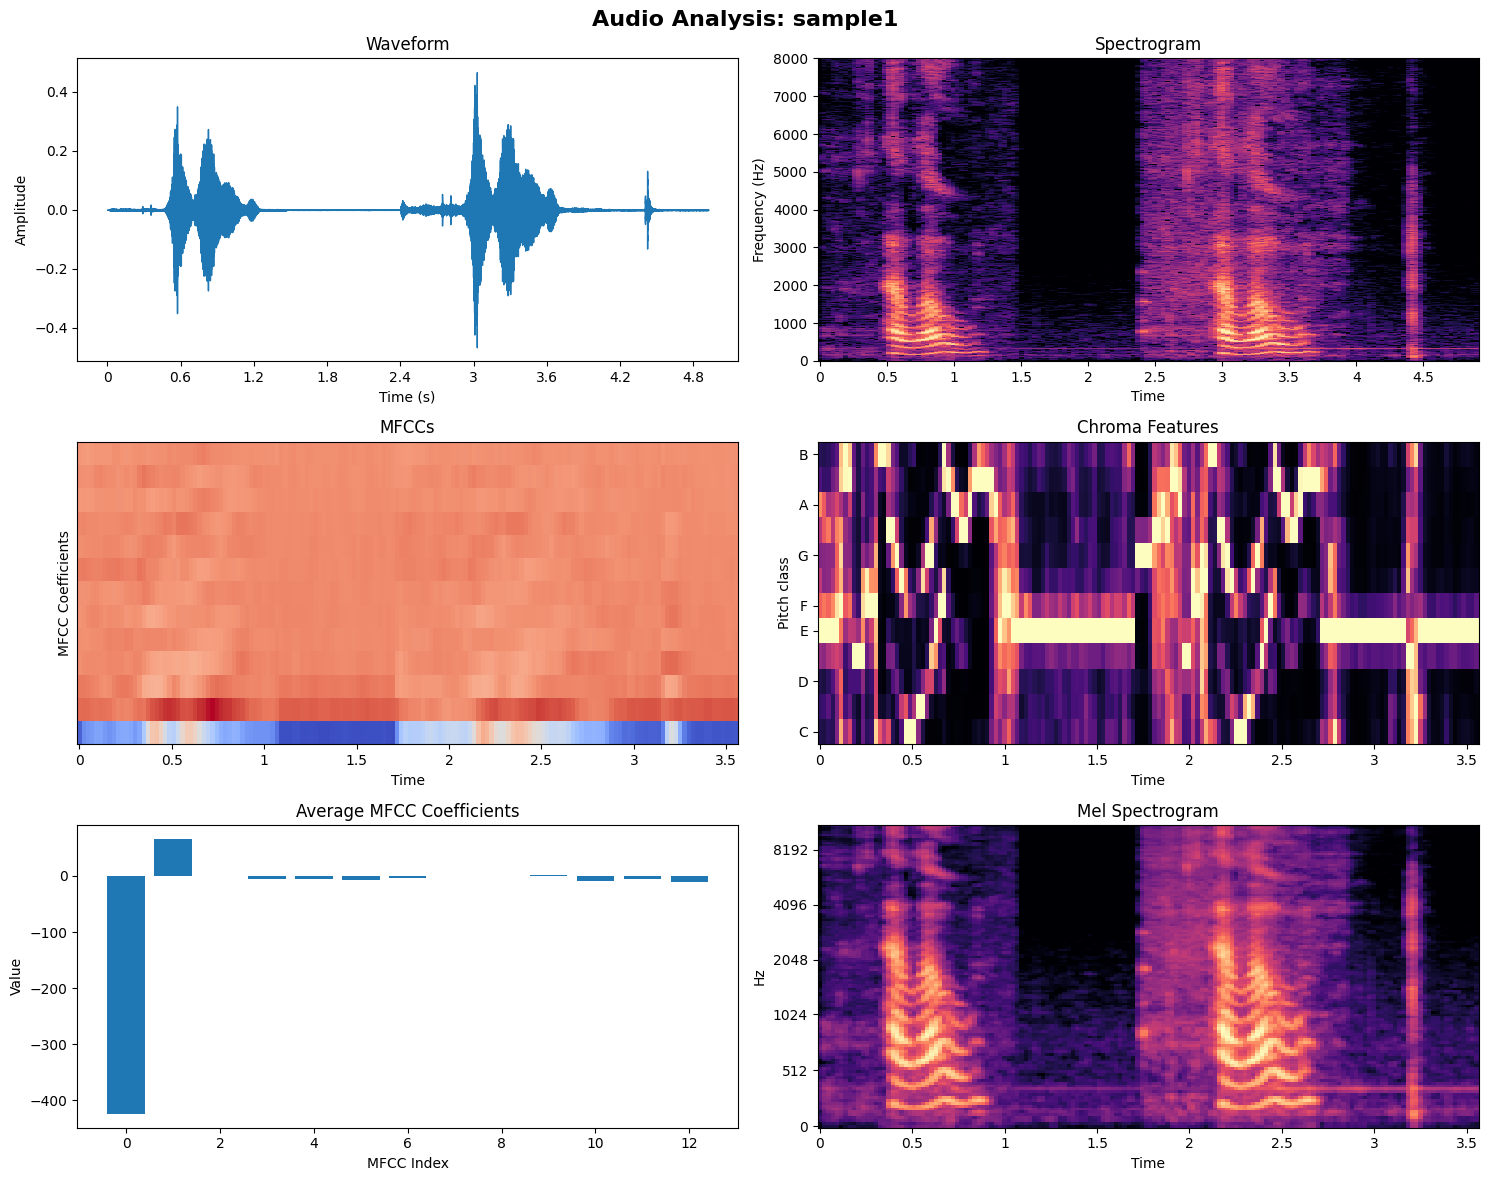

🎙️ Recording sample 2/3 for janedoe


<IPython.core.display.Javascript object>

✅ Sample 2 saved
📊 Creating analysis for sample 2...
📊 Graph saved to: /content/drive/MyDrive/voice_graphs/sample2_analysis_20250826_060543.png


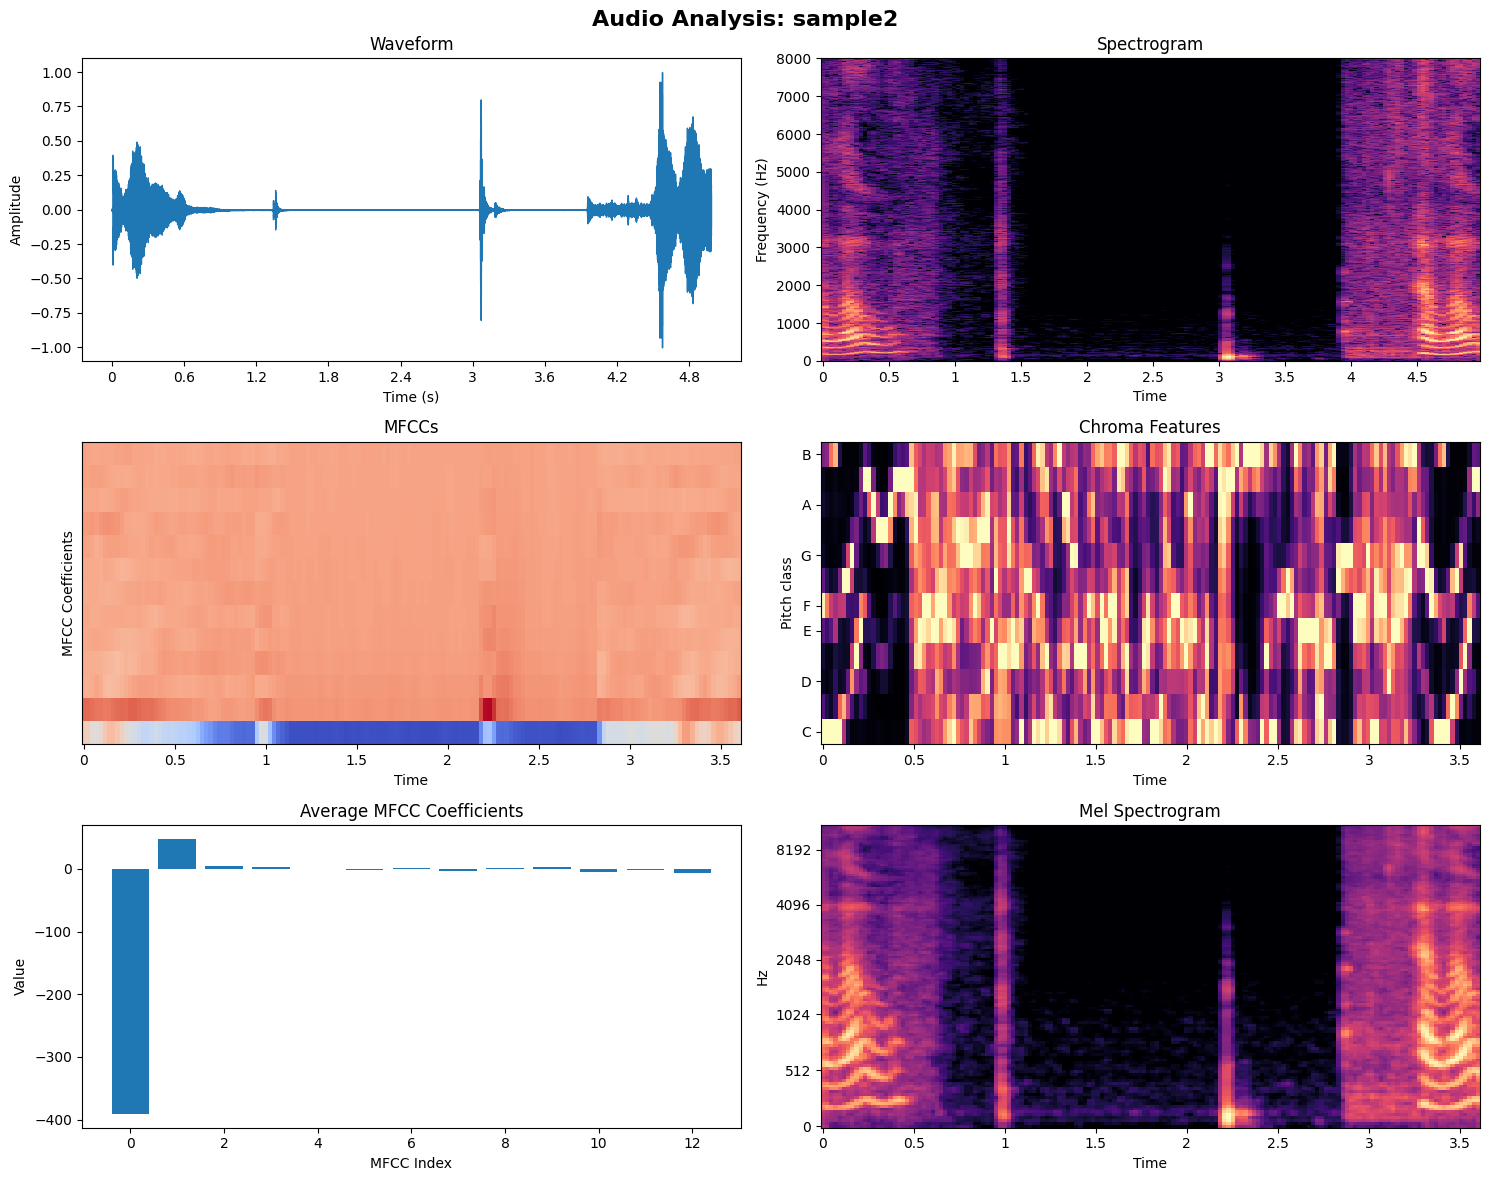

🎙️ Recording sample 3/3 for janedoe


<IPython.core.display.Javascript object>

✅ Sample 3 saved
📊 Creating analysis for sample 3...
📊 Graph saved to: /content/drive/MyDrive/voice_graphs/sample3_analysis_20250826_060553.png


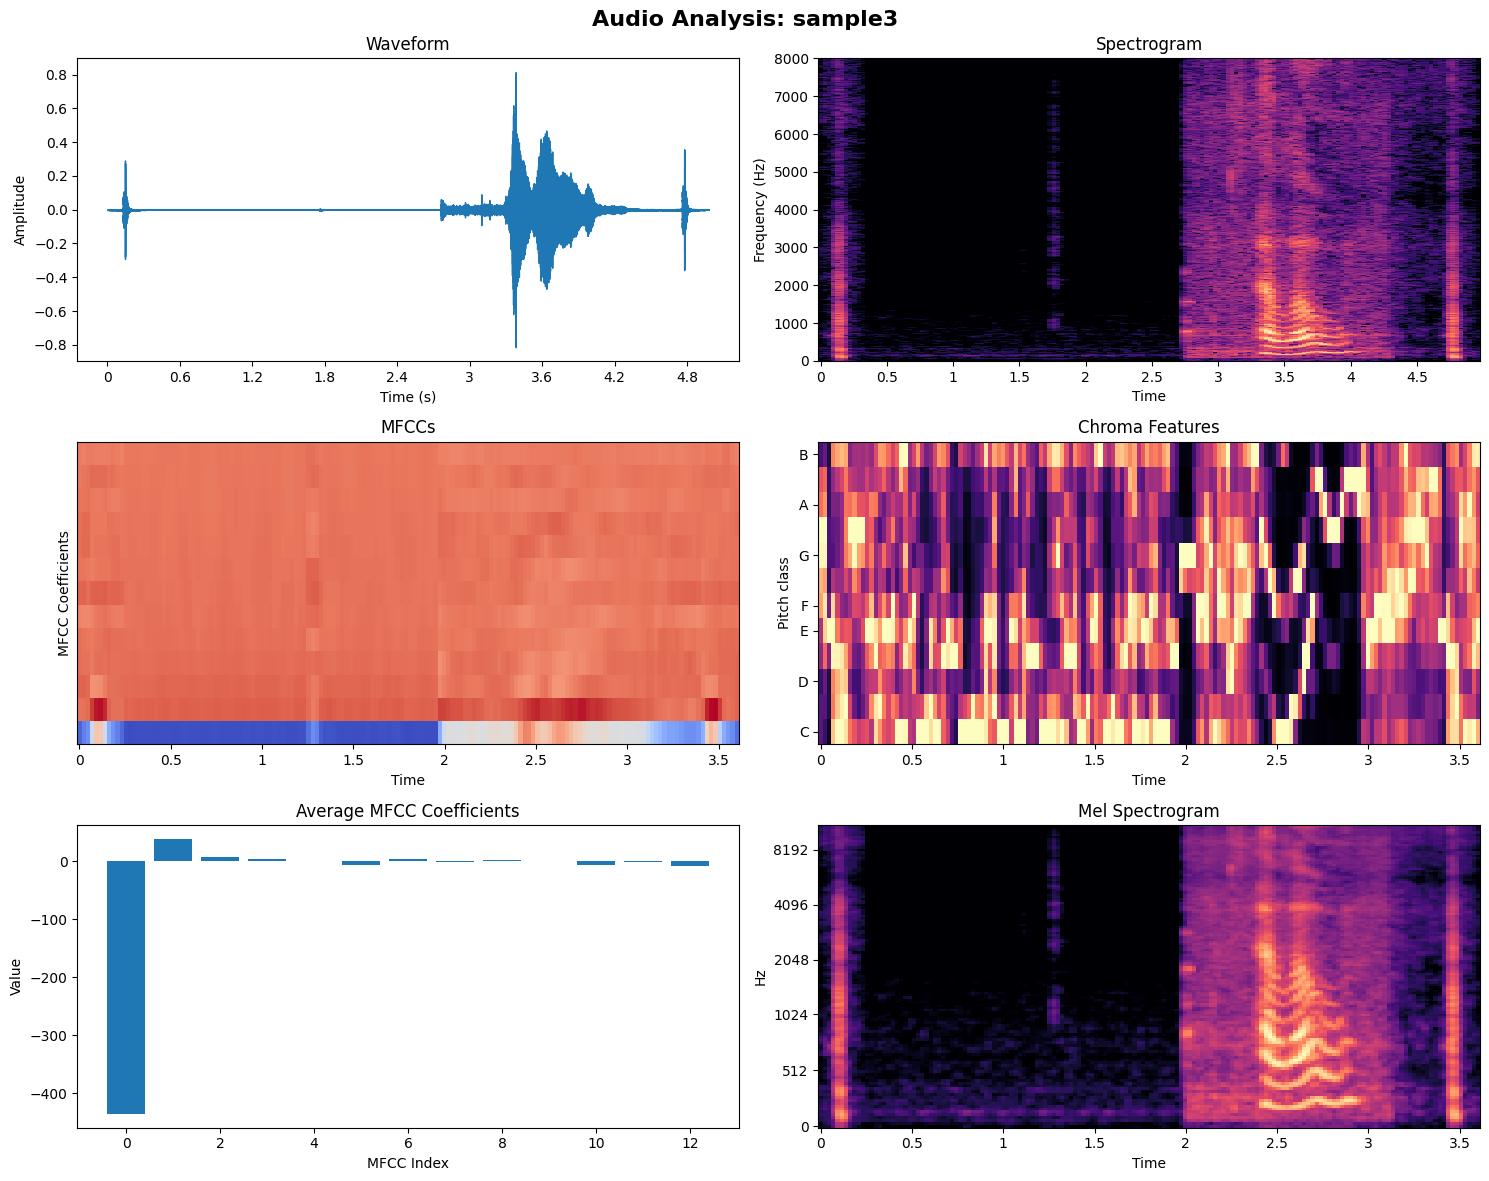

✅ Enrolled janedoe with 3 samples


['/content/drive/MyDrive/voice_enrollments/train/janedoe/sample1.wav',
 '/content/drive/MyDrive/voice_enrollments/train/janedoe/sample2.wav',
 '/content/drive/MyDrive/voice_enrollments/train/janedoe/sample3.wav']

In [ ]:
enroll_user_multiple('janedoe', 3)

🎙️ Recording sample 1/3 for Justin


<IPython.core.display.Javascript object>

✅ Sample 1 saved
📊 Creating analysis for sample 1...
📊 Graph saved to: /content/drive/MyDrive/voice_graphs/sample1_analysis_20250826_060644.png


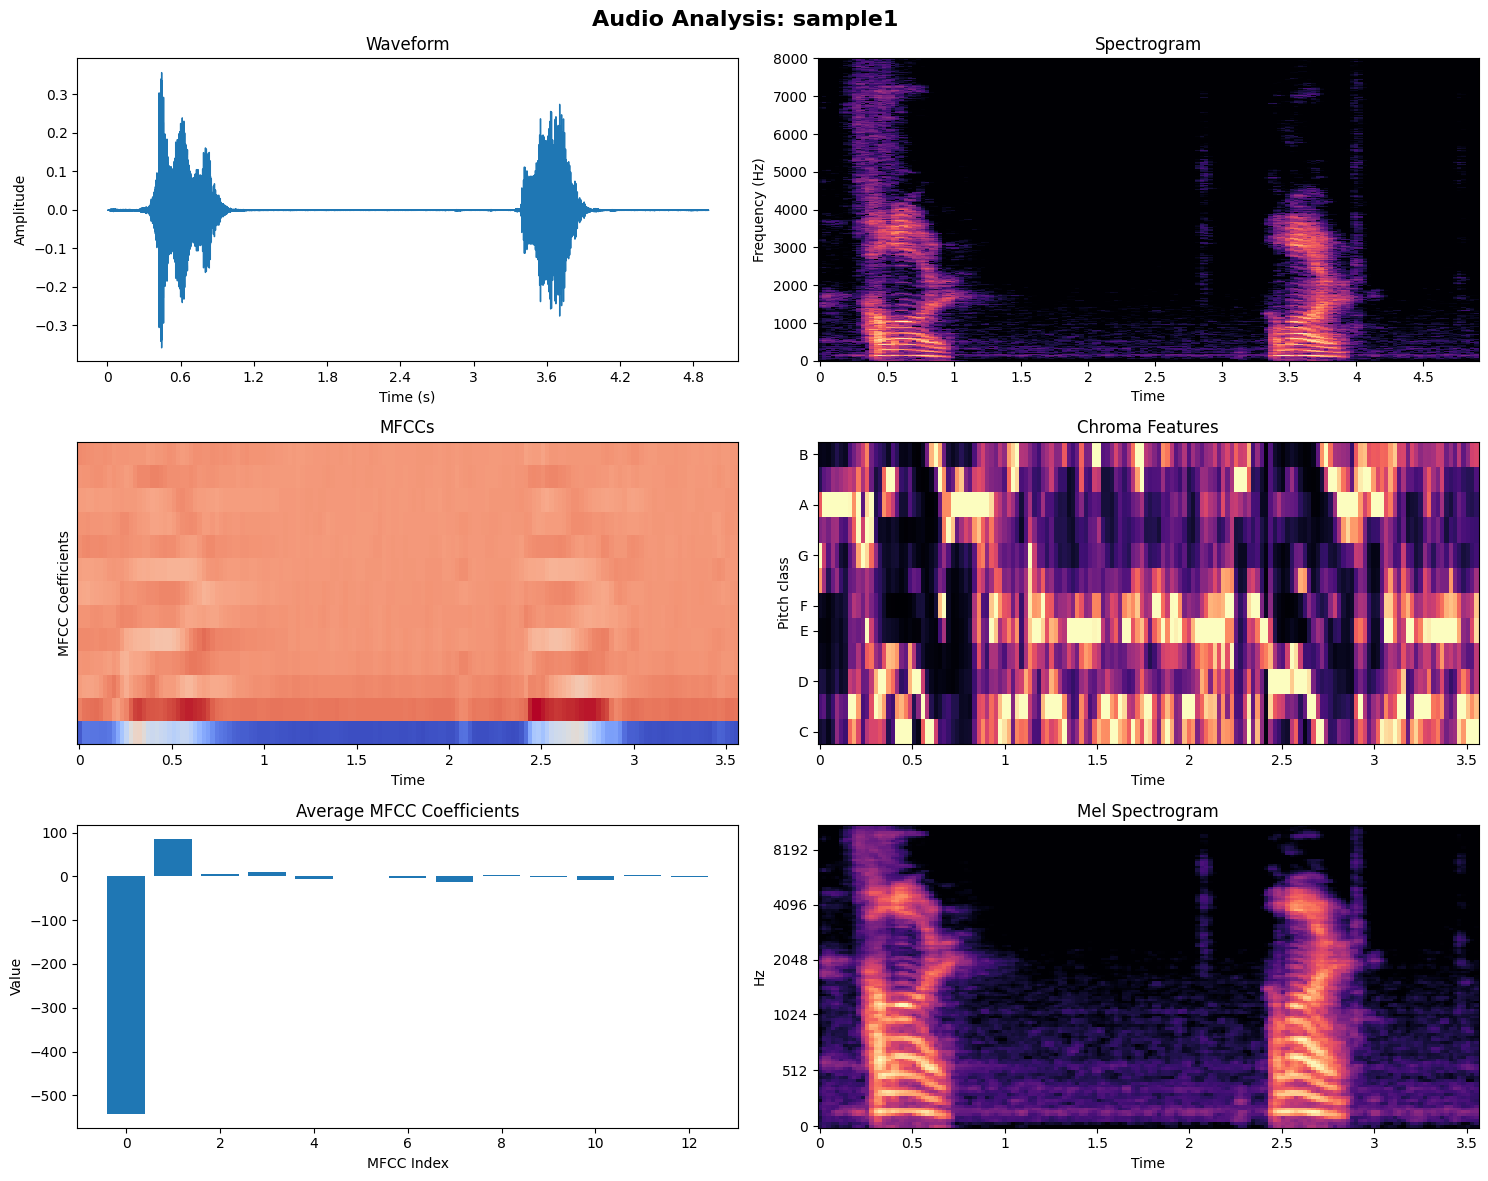

🎙️ Recording sample 2/3 for Justin


<IPython.core.display.Javascript object>

✅ Sample 2 saved
📊 Creating analysis for sample 2...
📊 Graph saved to: /content/drive/MyDrive/voice_graphs/sample2_analysis_20250826_060654.png


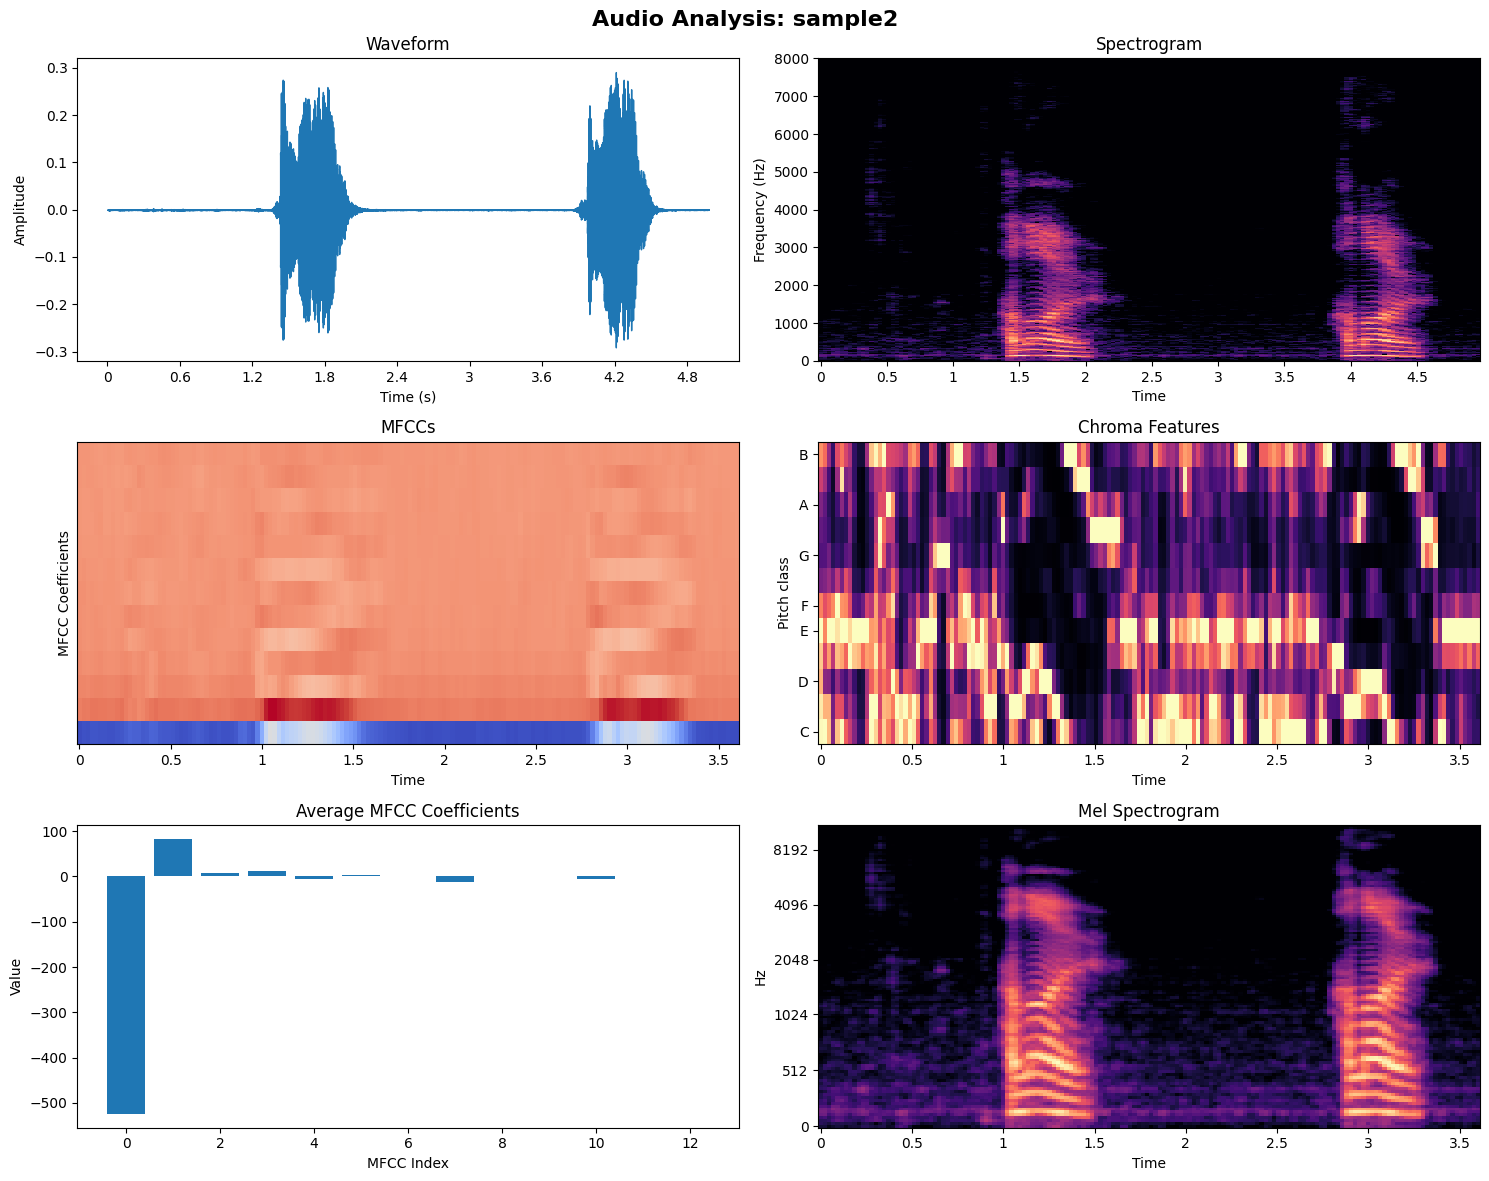

🎙️ Recording sample 3/3 for Justin


<IPython.core.display.Javascript object>

✅ Sample 3 saved
📊 Creating analysis for sample 3...
📊 Graph saved to: /content/drive/MyDrive/voice_graphs/sample3_analysis_20250826_060705.png


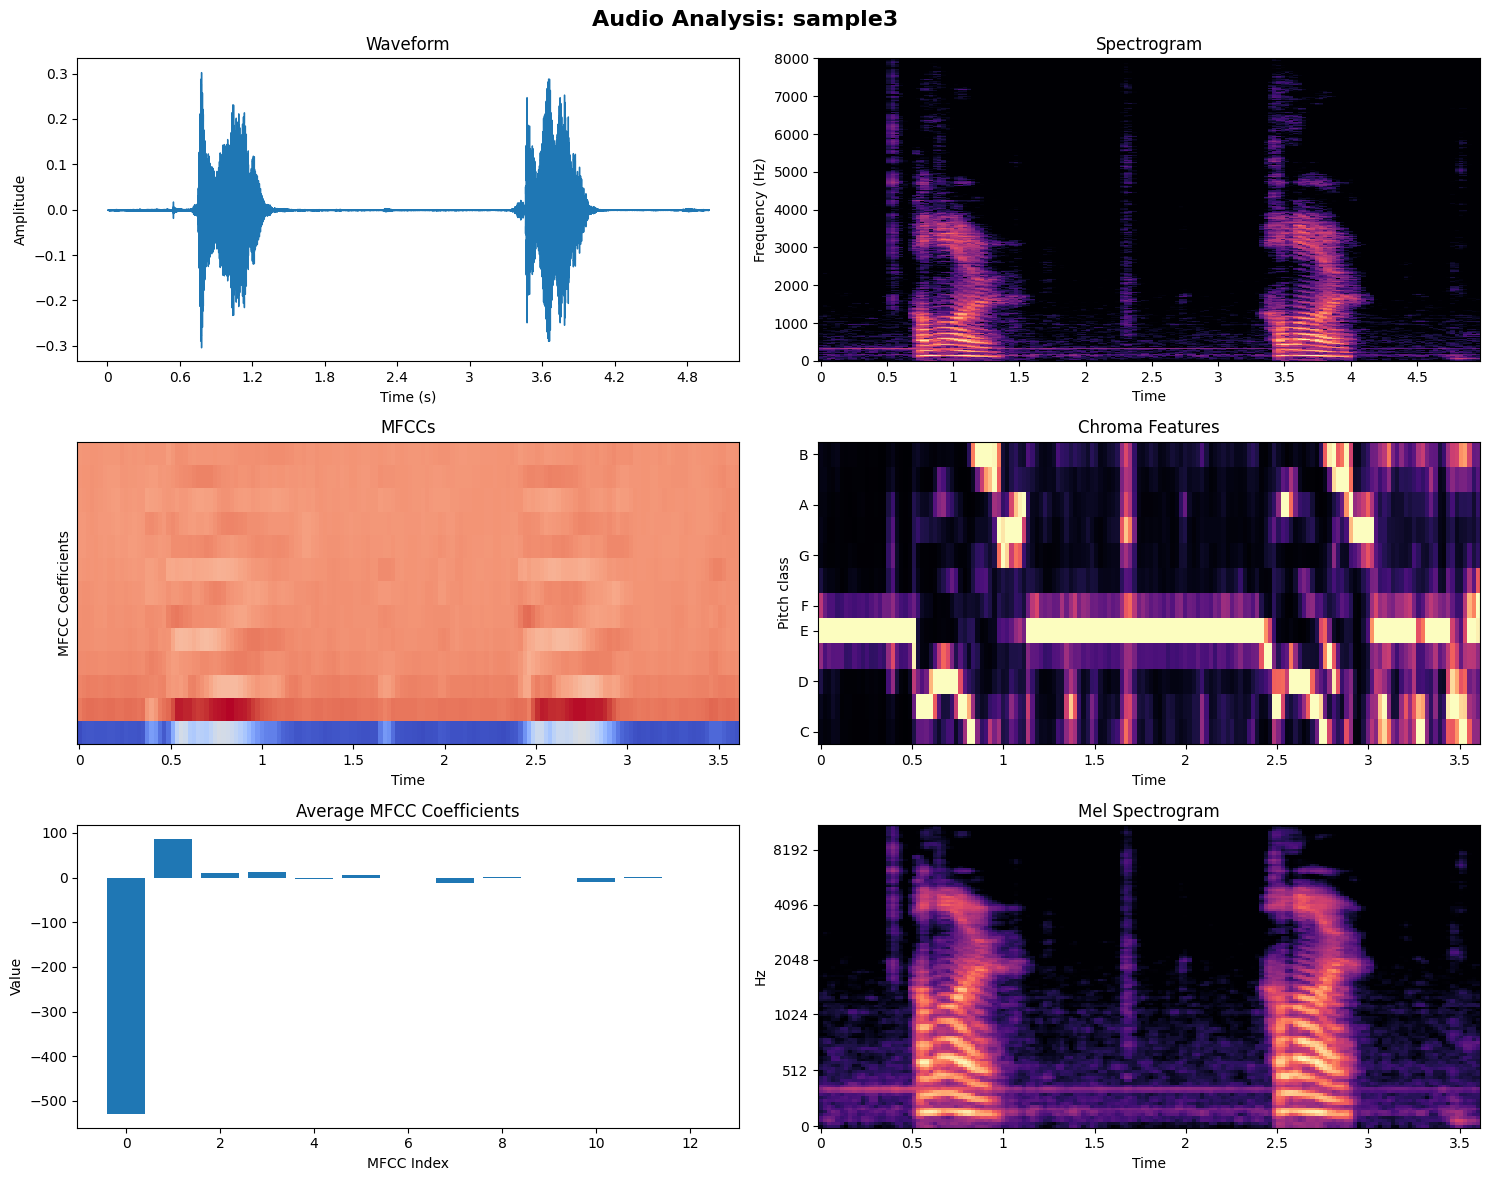

✅ Enrolled Justin with 3 samples


['/content/drive/MyDrive/voice_enrollments/train/Justin/sample1.wav',
 '/content/drive/MyDrive/voice_enrollments/train/Justin/sample2.wav',
 '/content/drive/MyDrive/voice_enrollments/train/Justin/sample3.wav']

In [ ]:
enroll_user_multiple('Justin', 3)


=== Step 1: Preparing dataset ===
Processing Test_ju: 3 files
Processing janedoe: 3 files
Processing bob: 0 files
Processing Justin: 3 files
Loaded 9 samples from 3 speakers

=== Step 2: Training model ===

=== Step 3: Evaluating model (Train/Test Split) ===


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Evaluation on held-out test set:
=== Classification Report ===
              precision    recall  f1-score   support

      Justin       0.50      1.00      0.67         1
     Test_ju       0.00      0.00      0.00         1
     janedoe       1.00      1.00      1.00         1

    accuracy                           0.67         3
   macro avg       0.50      0.67      0.56         3
weighted avg       0.50      0.67      0.56         3

=== Confusion Matrix ===
[[1 0 0]
 [1 0 0]
 [0 0 1]]

=== Step 4: Saving model ===
Model saved to /content/drive/MyDrive/voice_models/voice_model.pkl

=== Step 5: Reloading model ===
Model loaded from /content/drive/MyDrive/voice_models/voice_model.pkl

=== Step 6: Interactive testing ===

=== Interactive Testing with Comparison ===
Record test samples and compare them with enrolled audio!

--- Test 1/2 ---
Press Enter when ready to record a 5-second test sample...


<IPython.core.display.Javascript object>

📊 Creating analysis for test sample...
📊 Graph saved to: /content/drive/MyDrive/voice_graphs/test_sample_1_analysis_20250826_060948.png


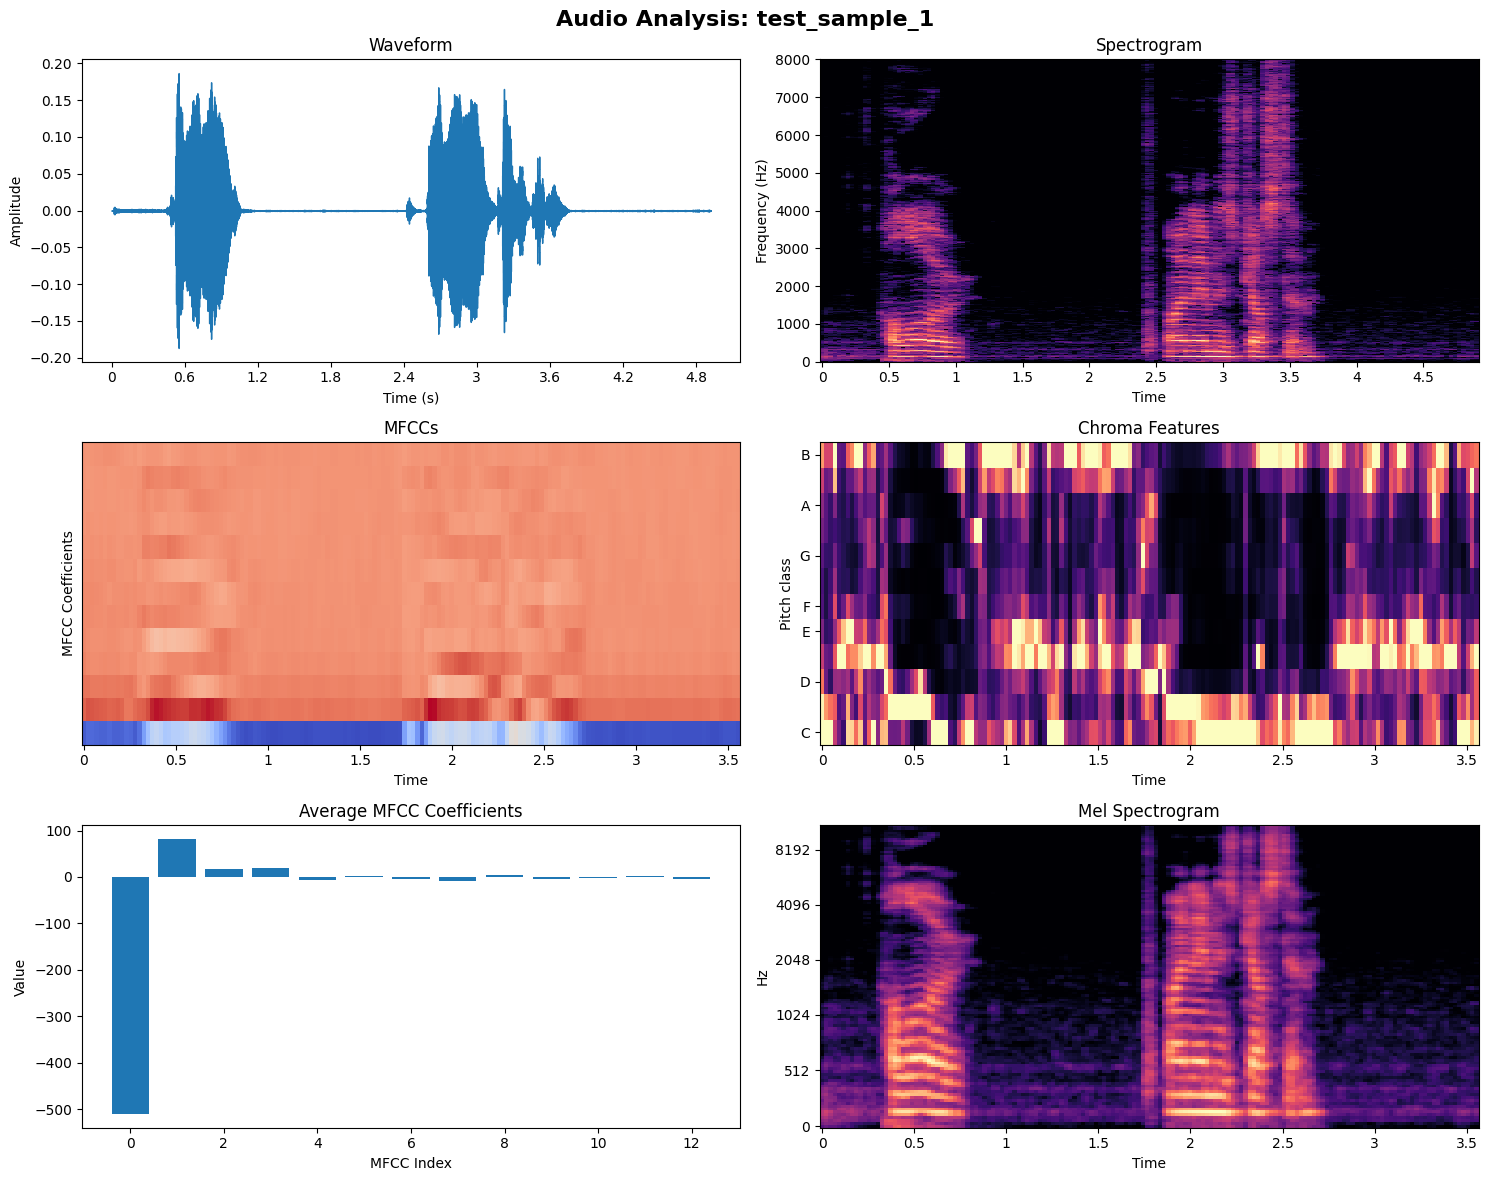


🤖 ML Model Result: ❌ Rejected
   Predicted Speaker: Test_ju
   Confidence: 0.530

🔍 Finding most similar enrolled recording...
🔍 Searching for similar audio in enrolled database...

📈 Top 5 Most Similar Enrolled Recordings:
   1. Justin/sample3.wav - Similarity: 0.9995
   2. Justin/sample2.wav - Similarity: 0.9994
   3. Justin/sample1.wav - Similarity: 0.9993
   4. Test_ju/sample1.wav - Similarity: 0.9981
   5. Test_ju/sample2.wav - Similarity: 0.9976

🎯 Best Match: Justin/sample3.wav (Similarity: 0.9995)


/tmp/ipython-input-1508248586.py:88: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()



📊 Audio Comparison Results:
   Cosine Similarity: 0.9995 (Higher = More Similar)
   Euclidean Distance: 25.1519 (Lower = More Similar)
   🎯 Very High Similarity - Likely Same Speaker
📊 Comparison graph saved to: /content/drive/MyDrive/voice_graphs/comparison_test_sample_1_vs_sample3_20250826_060959.png


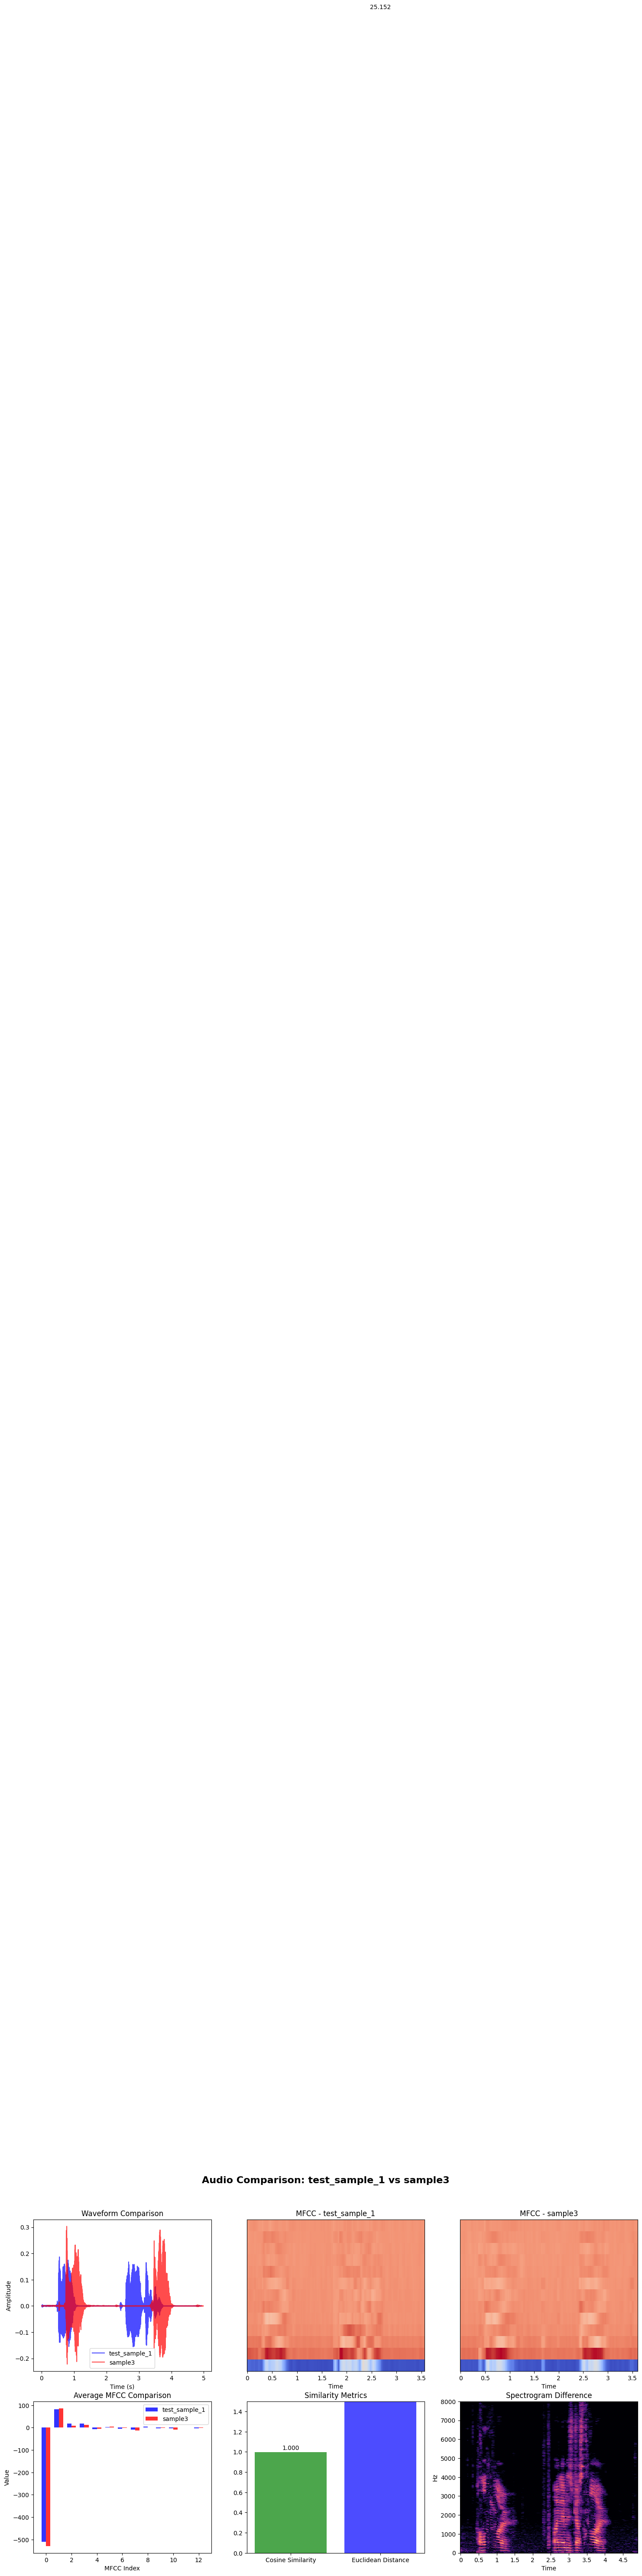


📊 Direct Audio Comparison Results:
   Most Similar: Justin
   Cosine Similarity: 0.9995
   Euclidean Distance: 25.1519
📁 Test file saved to: /content/drive/MyDrive/voice_enrollments/test/test_20250826_061009_1.wav

--- Test 2/2 ---
Press Enter when ready to record a 5-second test sample...


<IPython.core.display.Javascript object>

📊 Creating analysis for test sample...
📊 Graph saved to: /content/drive/MyDrive/voice_graphs/test_sample_2_analysis_20250826_061100.png


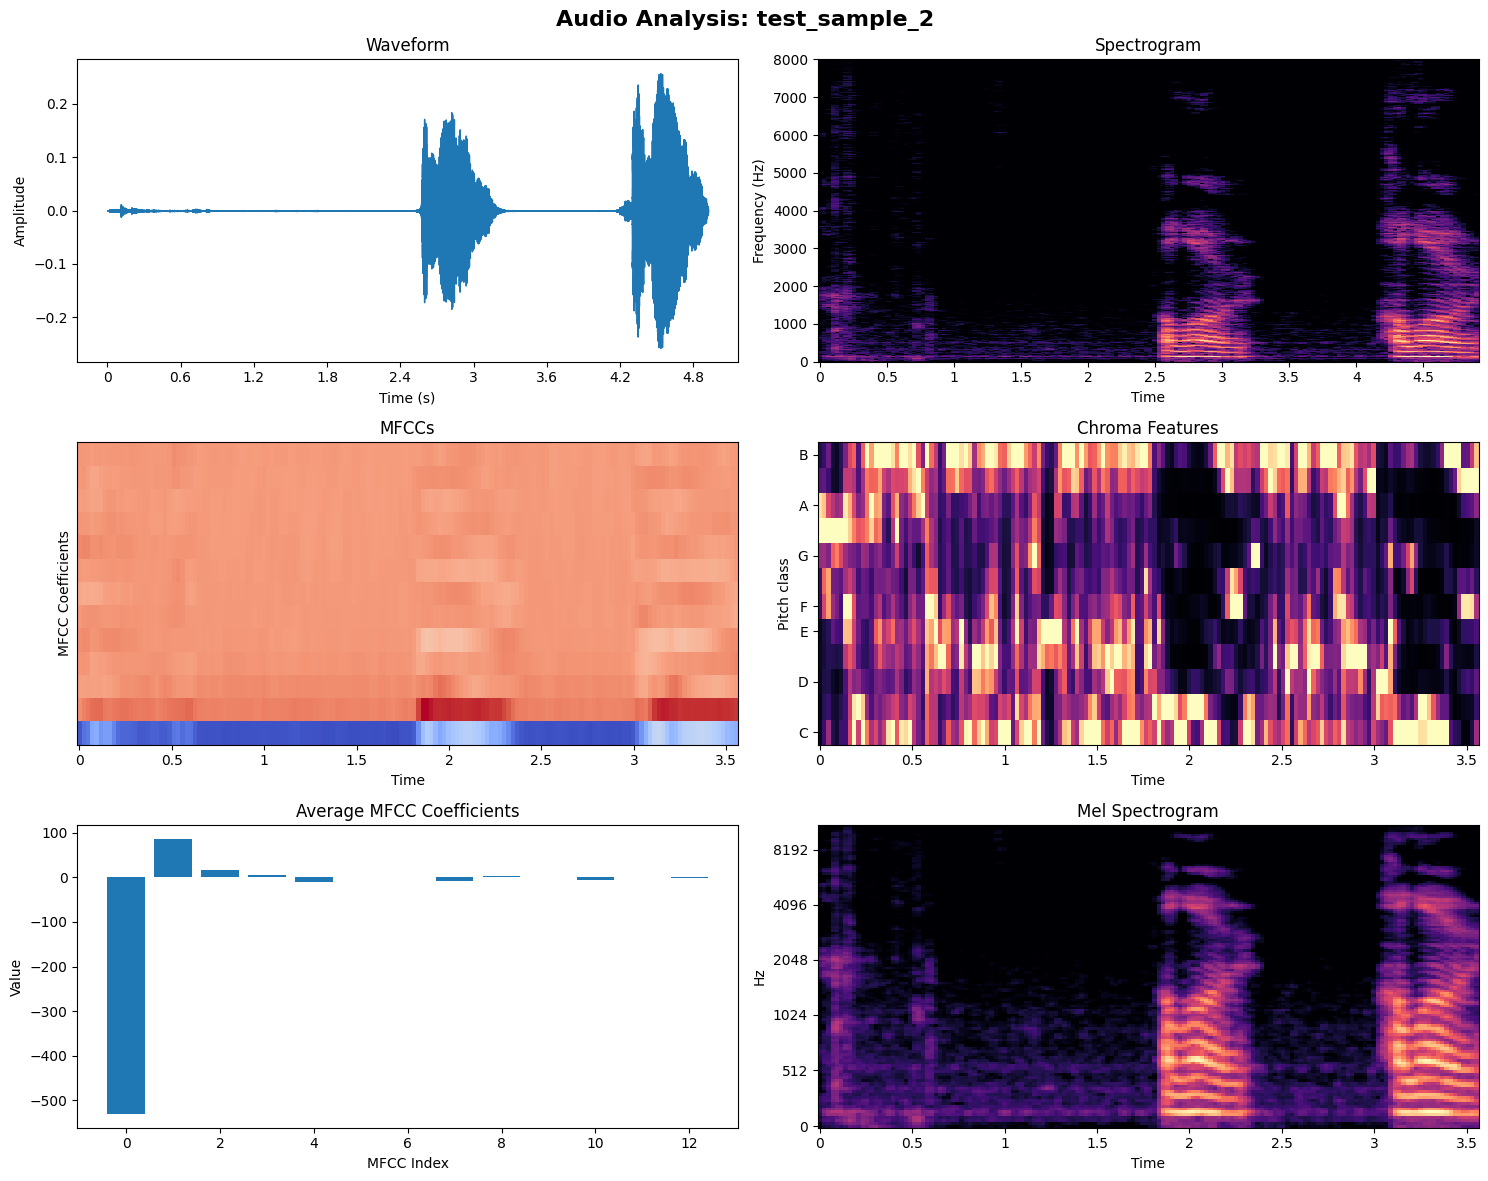


🤖 ML Model Result: ✅ Verified
   Predicted Speaker: Justin
   Confidence: 0.720

🔍 Finding most similar enrolled recording...
🔍 Searching for similar audio in enrolled database...

📈 Top 5 Most Similar Enrolled Recordings:
   1. Justin/sample3.wav - Similarity: 0.9996
   2. Justin/sample2.wav - Similarity: 0.9996
   3. Justin/sample1.wav - Similarity: 0.9995
   4. Test_ju/sample1.wav - Similarity: 0.9979
   5. janedoe/sample1.wav - Similarity: 0.9978

🎯 Best Match: Justin/sample3.wav (Similarity: 0.9996)


/tmp/ipython-input-1508248586.py:88: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()



📊 Audio Comparison Results:
   Cosine Similarity: 0.9996 (Higher = More Similar)
   Euclidean Distance: 15.9367 (Lower = More Similar)
   🎯 Very High Similarity - Likely Same Speaker
📊 Comparison graph saved to: /content/drive/MyDrive/voice_graphs/comparison_test_sample_2_vs_sample3_20250826_061110.png


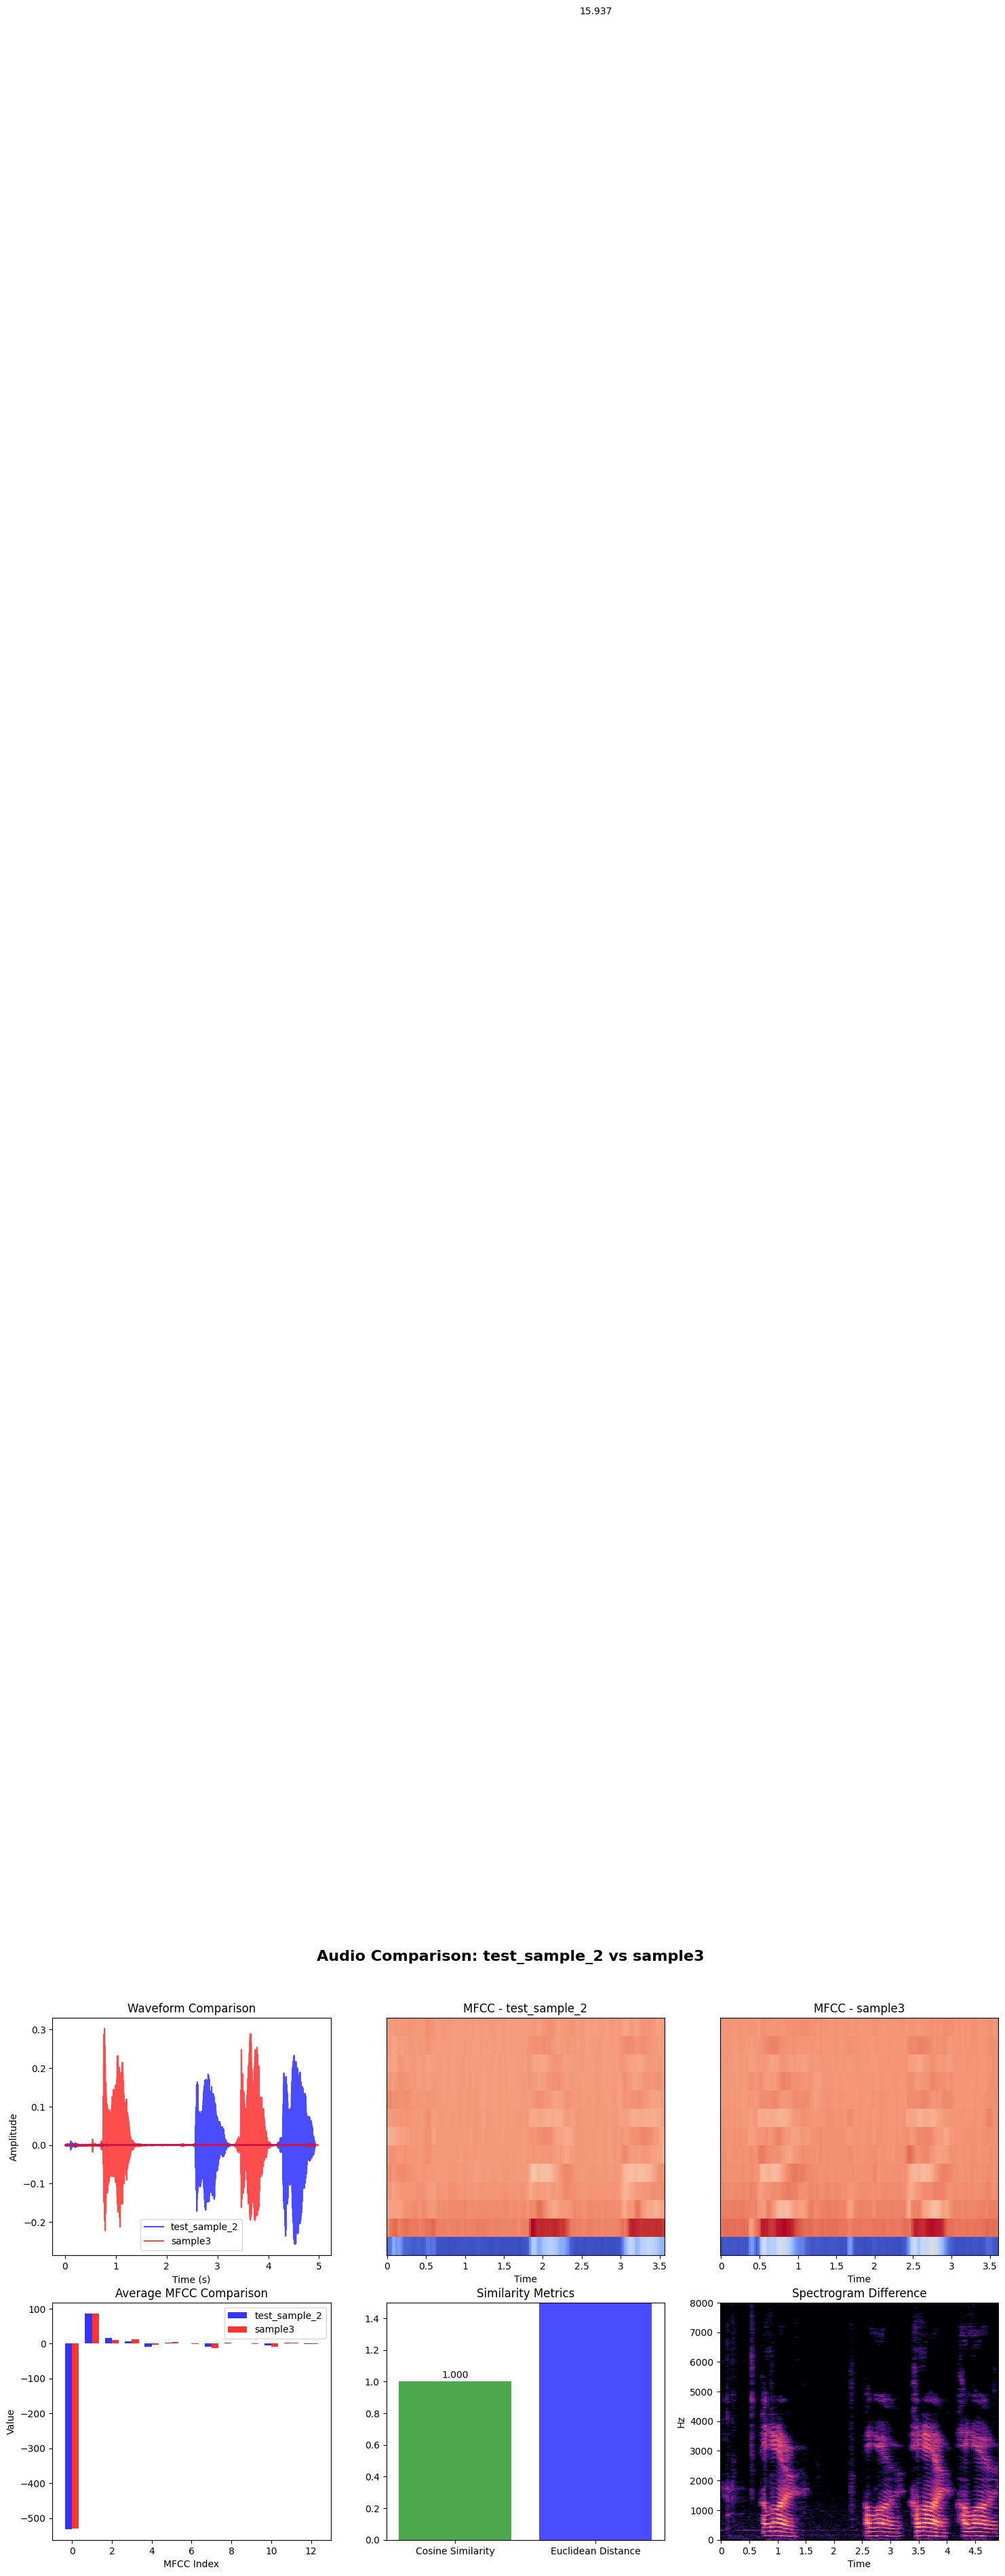


📊 Direct Audio Comparison Results:
   Most Similar: Justin
   Cosine Similarity: 0.9996
   Euclidean Distance: 15.9367
📁 Test file saved to: /content/drive/MyDrive/voice_enrollments/test/test_20250826_061118_2.wav


In [ ]:
MODEL_PATH = MODEL_DIR / 'voice_model.pkl'
run_demo(AUDIO_DIR, model_path=MODEL_PATH)